# 💳 Credit Card Fraud Detection using Machine Learning & Deep Learning

### End-to-End Machine Learning & Deep Learning Project

**Author:** Sandeep Vyas

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow, Keras, XGBoost

**Data Preprocessing:** StandardScaler, SMOTE (Handling Imbalanced Data)

**Machine Learning Models:**
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

**Deep Learning Models:**
- Artificial Neural Network (ANN)
- Autoencoder

**Project Type:** Binary Classification + Fraud Detection

**Dataset:** Credit Card Fraud Detection Dataset (Kaggle)

**Dataset Size:** 284,807 Transactions

**Features:** 30 Features (Time, V1–V28, Amount)

**Target Variable:**
- 0 → Genuine Transaction
- 1 → Fraud Transaction

**Evaluation Metrics:**
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

**Best Model:** XGBoost

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    confusion_matrix,classification_report,roc_auc_score,roc_curve)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

#SMOTE (Synthetic Minority Oversampling Technique)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(283726, 31)

In [11]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [12]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

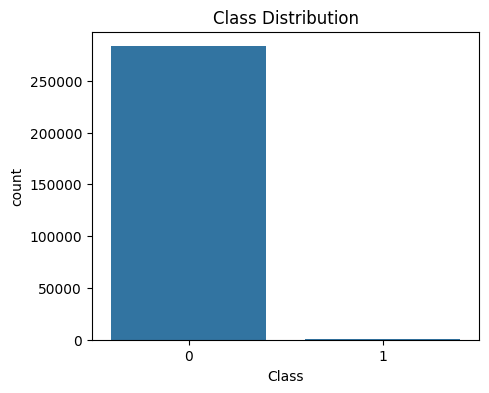

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [16]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

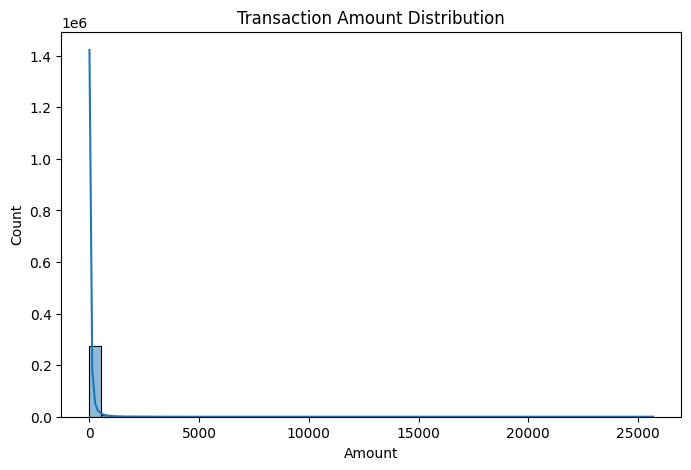

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"],bins=50,kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

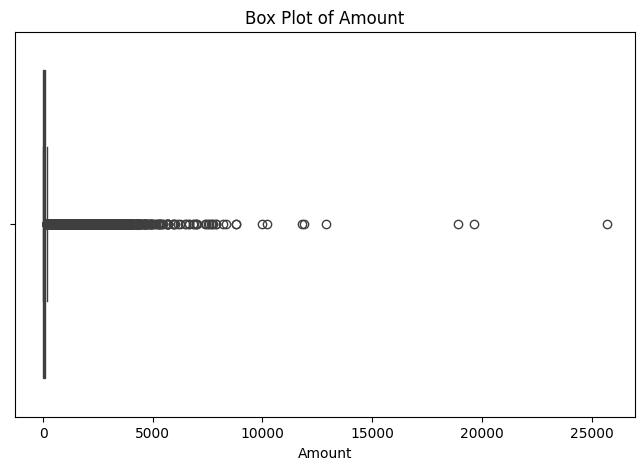

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Amount"])
plt.title("Box Plot of Amount")
plt.show()

In [19]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

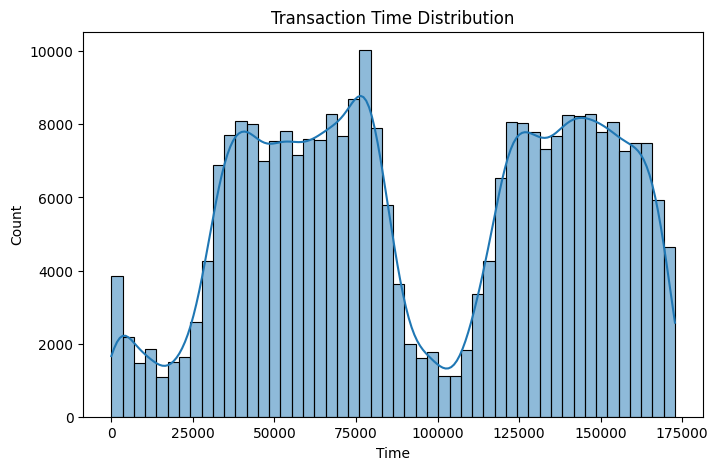

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"],bins=50,kde=True)
plt.title("Transaction Time Distribution")
plt.show()

In [21]:
corr=df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


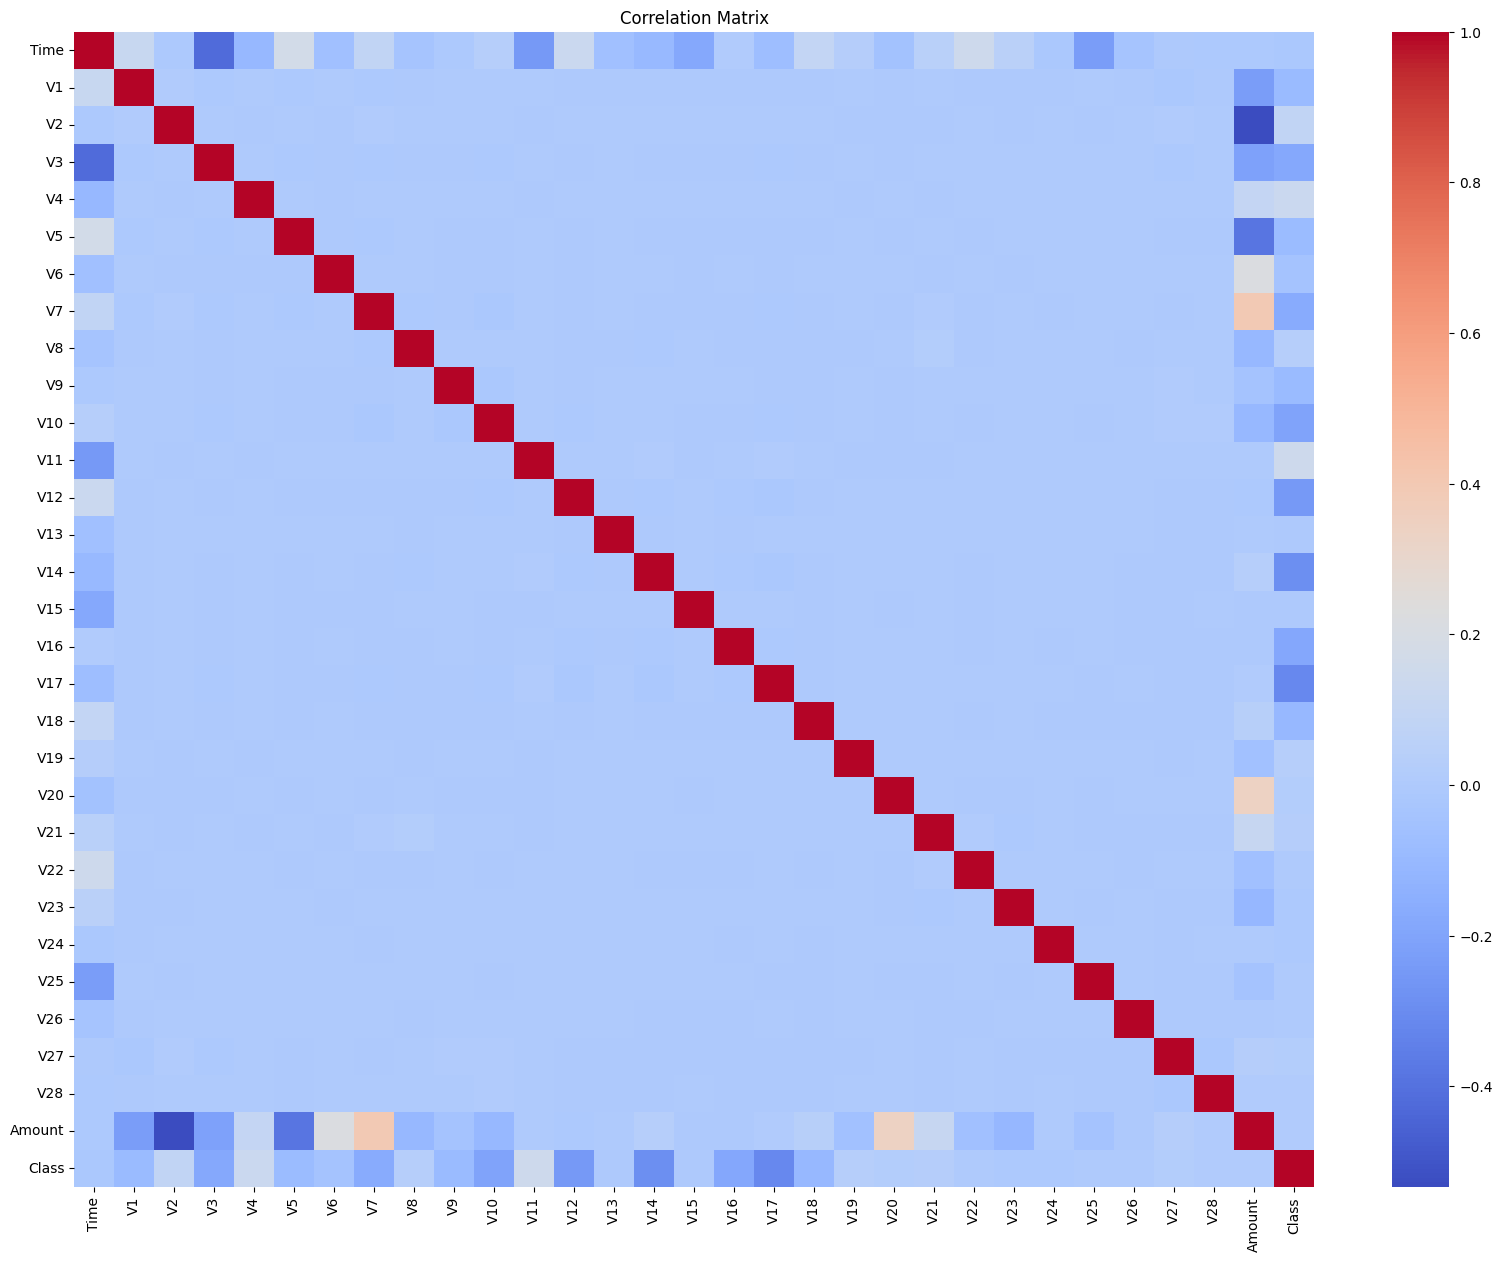

In [22]:
plt.figure(figsize=(20,15))
sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [23]:
df.corr()["Class"].sort_values(ascending=False)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

In [24]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [25]:
print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


In [28]:
scaler=StandardScaler()

In [29]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [30]:
X_train

array([[ 1.04549909,  1.14719836, -1.04203246, ...,  0.09278213,
        -0.15619266, -0.22943372],
       [-0.29869002, -0.67791131,  0.99194846, ..., -0.04986389,
         0.15383143, -0.33119698],
       [ 0.67839667,  0.97765362,  0.0162054 , ...,  0.11132947,
        -0.16581986, -0.29880852],
       ...,
       [ 1.19385202, -0.45214212,  0.70655379, ..., -0.62638332,
         0.28835592, -0.20908921],
       [-0.95824459,  0.63781446,  0.21468286, ...,  0.10812079,
         0.09533138, -0.3392941 ],
       [-0.89610272,  0.52361687, -0.13216317, ...,  0.1416972 ,
        -0.0070969 , -0.30955042]], shape=(226980, 30))

# SMOTE (Synthetic Minority Oversampling Technique)

In [31]:
smote = SMOTE(random_state=42)

In [32]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [33]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    226602
1    226602
Name: count, dtype: int64


# Logistic Regression

In [34]:
lr = LogisticRegression(random_state=42)

In [35]:
lr.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
y_pred_lr = lr.predict(X_test)

In [79]:
acc_lr = accuracy_score(y_test, y_pred_lr)
pre_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", acc_lr)
print("Precision :", pre_lr)
print("Recall :", rec_lr)
print("F1 Score :", f1_lr)
print("ROC AUC :", roc_lr)

Accuracy : 0.9736721531033025
Precision : 0.053035143769968054
Recall : 0.8736842105263158
F1 Score : 0.1
ROC AUC : 0.9626184886409772


In [80]:
print(confusion_matrix(y_test, y_pred_lr))

[[55169  1482]
 [   12    83]]


In [81]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [82]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [83]:
roc_auc_score(y_test, y_prob_lr)

0.9626184886409772

In [84]:
fpr, tpr, threshold = roc_curve(y_test, y_prob_lr)

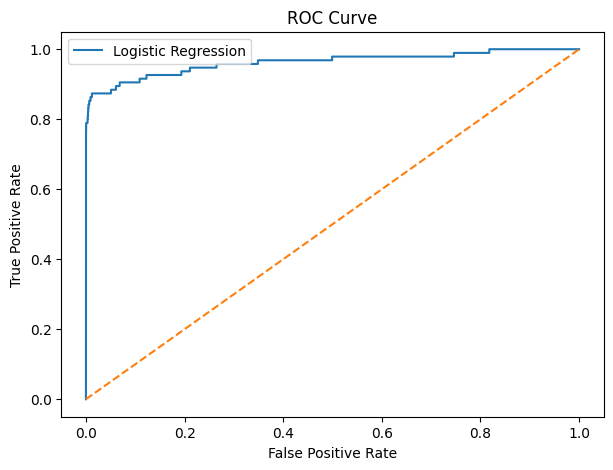

In [85]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Decision Tree

Accuracy : 0.9974095090402848
Precision : 0.3505747126436782
Recall : 0.6421052631578947
F1 Score : 0.45353159851301117
ROC AUC : 0.8200552970217462
[[56538   113]
 [   34    61]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.35      0.64      0.45        95

    accuracy                           1.00     56746
   macro avg       0.67      0.82      0.73     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC : 0.8200552970217462


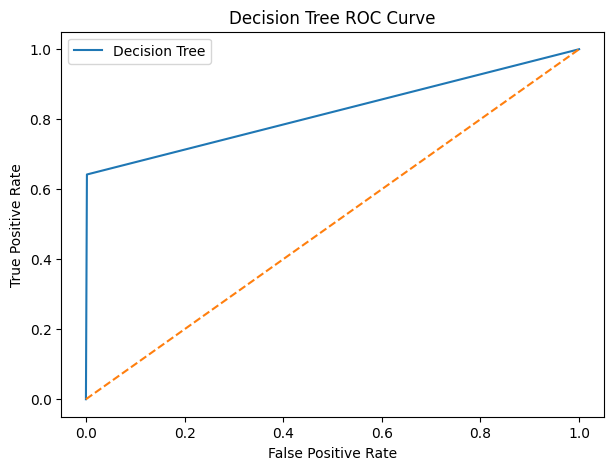

In [86]:
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_dt = dt.predict(X_test)

# Evaluation
acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", acc_dt)
print("Precision :", pre_dt)
print("Recall :", rec_dt)
print("F1 Score :", f1_dt)
print("ROC AUC :", roc_dt)

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print(classification_report(y_test, y_pred_dt))

# ROC-AUC
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("ROC AUC :", roc_auc_score(y_test, y_prob_dt))

# ROC Curve
fpr, tpr, threshold = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

# Random Forest Classifier

Accuracy : 0.9994889507630493
Precision : 0.9125
Recall : 0.7684210526315789
F1 Score : 0.8342857142857143
ROC AUC : 0.9694220104815354
[[56644     7]
 [   22    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC : 0.9694220104815354


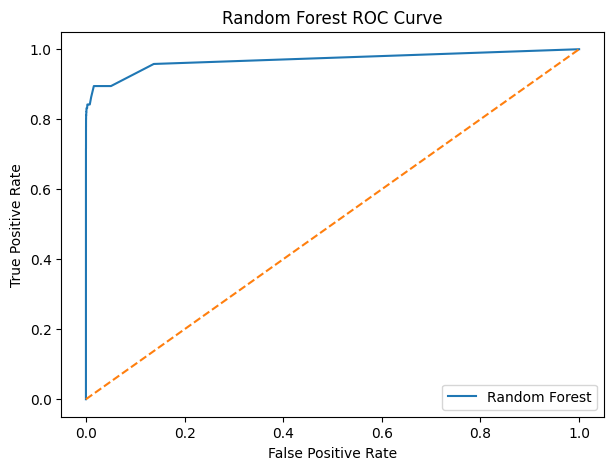

In [87]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", acc_rf)
print("Precision :", pre_rf)
print("Recall :", rec_rf)
print("F1 Score :", f1_rf)
print("ROC AUC :", roc_rf)

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:,1]

print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))

fpr, tpr, threshold = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

# XGBoost Classifier

Accuracy : 0.9991893701758714
Precision : 0.7425742574257426
Recall : 0.7894736842105263
F1 Score : 0.7653061224489796
ROC AUC : 0.9701540085230994
[[56625    26]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.74      0.79      0.77        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC : 0.9701540085230994


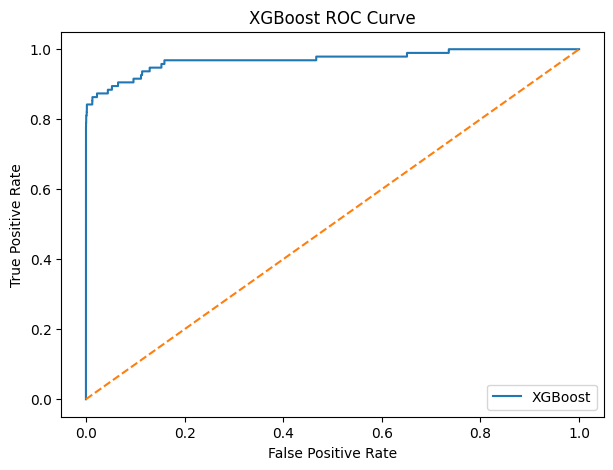

In [88]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss")

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
pre_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", acc_xgb)
print("Precision :", pre_xgb)
print("Recall :", rec_xgb)
print("F1 Score :", f1_xgb)
print("ROC AUC :", roc_xgb)

print(confusion_matrix(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("ROC AUC :", roc_auc_score(y_test, y_prob_xgb))

fpr, tpr, threshold = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

# ANN (Artificial Neural Network)

In [47]:
ann = Sequential([
    
    Input(shape=(X_train_smote.shape[1],)),Dense(32, activation='relu'),
    Dense(16, activation='relu'),Dense(1, activation='sigmoid')])

In [48]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [50]:
history = ann.fit(X_train_smote,y_train_smote,epochs=20,
    batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9918 - loss: 0.0254 - val_accuracy: 0.9995 - val_loss: 0.0071
Epoch 2/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0.9992 - val_loss: 0.0027
Epoch 3/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 50s 4ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 0.9999 - val_loss: 0.0012
Epoch 4/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 0.9995 - val_loss: 0.0019
Epoch 5/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 6.3954e-04
Epoch 6/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 4.6226e-04
Epoch 7/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 56s 5ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 4.3620e-04
Epoch 8/20
11331/11331 ━━━━━━━━━━━━━━━━━━━━ 74s 4ms/step 

In [51]:
y_prob_ann = ann.predict(X_test)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [52]:
y_pred_ann = (y_prob_ann > 0.5).astype(int)

In [89]:
acc_ann = accuracy_score(y_test, y_pred_ann)
pre_ann = precision_score(y_test, y_pred_ann)
rec_ann = recall_score(y_test, y_pred_ann)
f1_ann = f1_score(y_test, y_pred_ann)
roc_ann = roc_auc_score(y_test, y_prob_ann)

print("Accuracy :", acc_ann)
print("Precision :", pre_ann)
print("Recall :", rec_ann)
print("F1 Score :", f1_ann)
print("ROC AUC :", roc_ann)

Accuracy : 0.9990836358509851
Precision : 0.7047619047619048
Recall : 0.7789473684210526
F1 Score : 0.74
ROC AUC : 0.9429873955864578


[[56620    31]
 [   21    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.78      0.74        95

    accuracy                           1.00     56746
   macro avg       0.85      0.89      0.87     56746
weighted avg       1.00      1.00      1.00     56746

ROC AUC : 0.9429873955864578


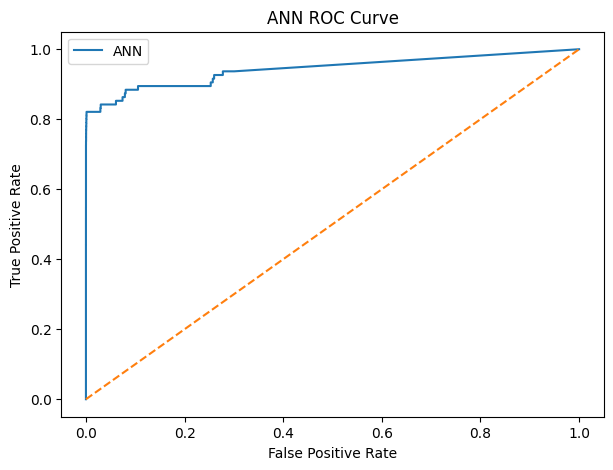

In [90]:
print(confusion_matrix(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))
print("ROC AUC :", roc_auc_score(y_test, y_prob_ann))

fpr, tpr, threshold = roc_curve(y_test, y_prob_ann)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="ANN")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.legend()
plt.show()

# Autoencoder Model

In [67]:
# Only Genuine Transactions
X_train_normal = X_train[y_train == 0]
print(X_train_normal.shape)

(226602, 30)


In [68]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(8, activation="relu")(encoder)

latent = Dense(4, activation="relu")(encoder)

decoder = Dense(8, activation="relu")(latent)
decoder = Dense(16, activation="relu")(decoder)

output_layer = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

In [69]:
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 30)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,362 (5.32 KB)

 Trainable params: 1,362 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
autoencoder.compile(optimizer="adam",loss="mse")

In [71]:
history = autoencoder.fit(X_train_normal,X_train_normal,epochs=20,
    batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.7149 - val_loss: 0.6388
Epoch 2/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.6044 - val_loss: 0.5908
Epoch 3/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.5664 - val_loss: 0.5642
Epoch 4/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.5506 - val_loss: 0.5514
Epoch 5/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.5433 - val_loss: 0.5463
Epoch 6/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.5379 - val_loss: 0.5422
Epoch 7/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - loss: 0.5345 - val_loss: 0.5398
Epoch 8/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.5313 - val_loss: 0.5393
Epoch 9/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.5285 - val_loss: 0.5335
Epoch 10/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.5259 - val_loss: 0.5417
Epoch 11/20
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 0.5229 - val_loss: 0.5472
Epoch 12/20
5666/56

In [72]:
reconstructed = autoencoder.predict(X_test)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [73]:
mse = np.mean(np.power(X_test - reconstructed, 2), axis=1)
threshold = np.percentile(mse,95)
y_pred_auto = (mse > threshold).astype(int)

In [91]:
acc_auto = accuracy_score(y_test, y_pred_auto)
pre_auto = precision_score(y_test, y_pred_auto)
rec_auto = recall_score(y_test, y_pred_auto)
f1_auto = f1_score(y_test, y_pred_auto)
roc_auto = roc_auc_score(y_test, mse)

print("Accuracy :", acc_auto)
print("Precision :", pre_auto)
print("Recall :", rec_auto)
print("F1 Score :", f1_auto)
print("ROC AUC :", roc_auto)

Accuracy : 0.9509921404151834
Precision : 0.026779422128259338
Recall : 0.8
F1 Score : 0.051824070917149676
ROC AUC : 0.9332598764921696


[[53889  2762]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.80      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.88      0.51     56746
weighted avg       1.00      0.95      0.97     56746

ROC AUC : 0.9332598764921696


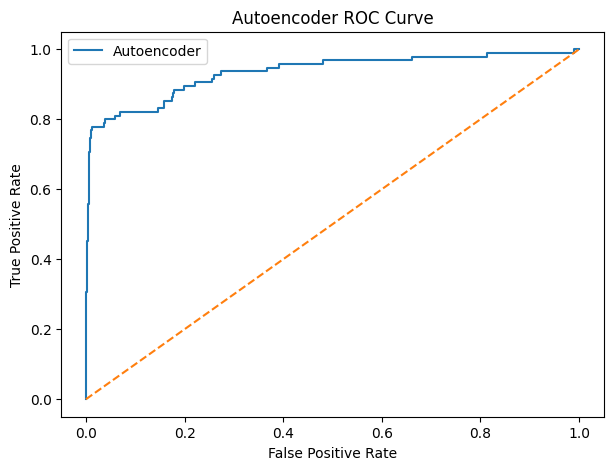

In [92]:
print(confusion_matrix(y_test,y_pred_auto))
print(classification_report(y_test,y_pred_auto))
print("ROC AUC :", roc_auc_score(y_test,mse))

fpr, tpr, threshold = roc_curve(y_test,mse)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label="Autoencoder")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Autoencoder ROC Curve")
plt.legend()
plt.show()

In [94]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest",
        "XGBoost","ANN","Autoencoder"],
    
    "Accuracy": [acc_lr, acc_dt, acc_rf, acc_xgb, acc_ann, acc_auto],
    "Precision": [pre_lr, pre_dt, pre_rf, pre_xgb, pre_ann, pre_auto],
    "Recall": [rec_lr, rec_dt, rec_rf, rec_xgb, rec_ann, rec_auto],
    "F1 Score": [f1_lr, f1_dt, f1_rf, f1_xgb, f1_ann, f1_auto],
    "ROC-AUC": [roc_lr, roc_dt, roc_rf, roc_xgb, roc_ann, roc_auto]})

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9626
1,Decision Tree,0.9974,0.3506,0.6421,0.4535,0.8201
2,Random Forest,0.9995,0.9125,0.7684,0.8343,0.9694
3,XGBoost,0.9992,0.7426,0.7895,0.7653,0.9702
4,ANN,0.9991,0.7048,0.7789,0.7400,0.9430
5,Autoencoder,0.9510,0.0268,0.8000,0.0518,0.9333


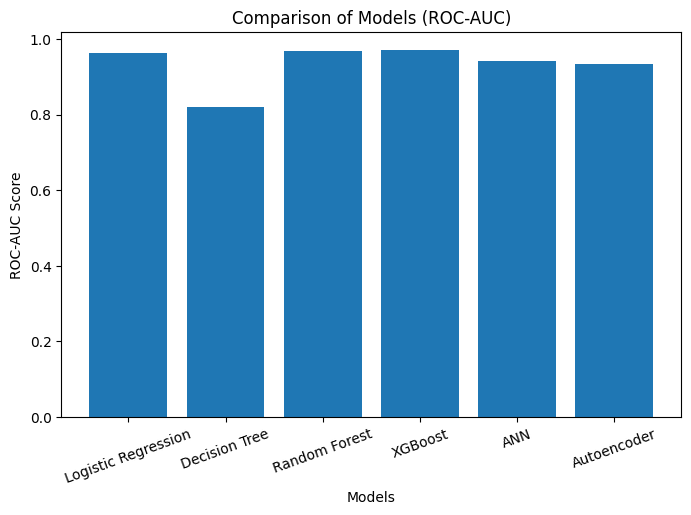

In [95]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["ROC-AUC"])

plt.xticks(rotation=20)

plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("Comparison of Models (ROC-AUC)")

plt.show()

In [96]:
results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.9992,0.7426,0.7895,0.7653,0.9702
2,Random Forest,0.9995,0.9125,0.7684,0.8343,0.9694
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9626
4,ANN,0.9991,0.7048,0.7789,0.7400,0.9430
5,Autoencoder,0.9510,0.0268,0.8000,0.0518,0.9333
1,Decision Tree,0.9974,0.3506,0.6421,0.4535,0.8201


In [98]:
import joblib
joblib.dump(xgb, "best_model.pkl")

['best_model.pkl']

In [99]:
best_model = joblib.load("best_model.pkl")

In [100]:
prediction = best_model.predict(X_test)
print(prediction[:10])

[0 0 0 0 0 0 0 0 0 0]


In [102]:
importance = xgb.feature_importances_

feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": importance})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

feature_importance

,Feature,Importance
14,V14,0.623504
4,V4,0.053825
8,V8,0.027731
10,V10,0.023046
12,V12,0.020693
9,V9,0.017684
13,V13,0.016250
11,V11,0.015808
17,V17,0.015430
19,V19,0.013466


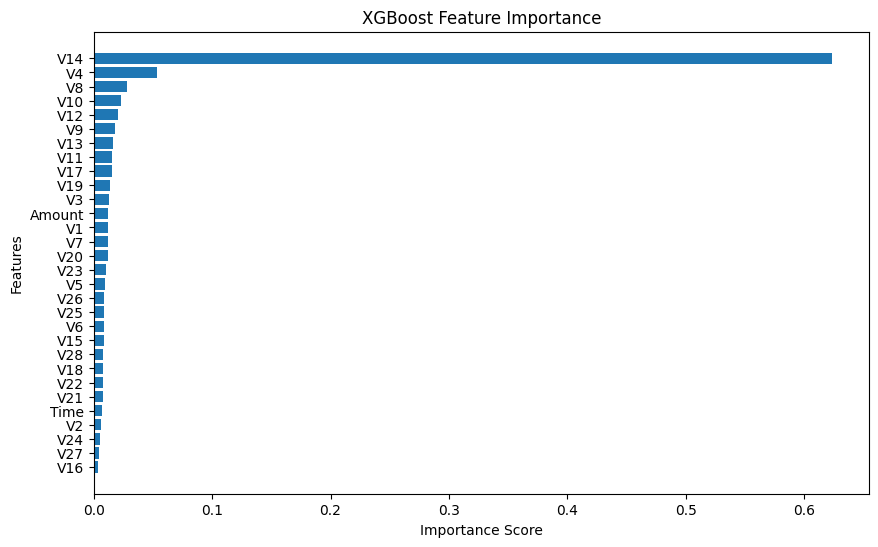

In [103]:
plt.figure(figsize=(10,6))

plt.barh(feature_importance["Feature"],feature_importance["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()
plt.show()

<div style="background-color:#111827;
            color:white;
            padding:30px;
            border-radius:15px;
            text-align:center;
            box-shadow:0px 0px 15px gray;">

<h1>💳 Credit Card Fraud Detection using Machine Learning & Deep Learning</h1>

<h2>End-to-End Machine Learning & Deep Learning Project</h2>

</div>

<br>

<div style="background-color:#F0FFF4;
            border-left:8px solid #22C55E;
            padding:20px;
            border-radius:10px;">

<h2>🎯 Project Objective</h2>

<p>

Build a complete End-to-End Credit Card Fraud Detection pipeline using
Machine Learning and Deep Learning techniques including:

</p>

<ul>

<li>✅ Data Loading</li>

<li>✅ Data Cleaning</li>

<li>✅ Duplicate Record Removal</li>

<li>✅ Exploratory Data Analysis (EDA)</li>

<li>✅ Feature Scaling</li>

<li>✅ Handling Imbalanced Data using SMOTE</li>

<li>✅ Machine Learning Model Building</li>

<li>✅ Deep Learning Model Building (ANN)</li>

<li>✅ Autoencoder (Anomaly Detection)</li>

<li>✅ Model Evaluation</li>

<li>✅ ROC Curve Analysis</li>

<li>✅ Model Comparison</li>

<li>✅ Best Model Selection</li>

<li>✅ Model Saving</li>

<li>✅ Fraud Transaction Prediction</li>

</ul>

</div>

<br>

# 📂 Project Workflow

---

## ✅ Data Collection

- Imported Credit Card Fraud Detection Dataset
- Imported Required Libraries
- Loaded Dataset into Pandas DataFrame

---

## ✅ Data Understanding

- Dataset Shape
- Dataset Information
- Data Types
- First Five Rows
- Statistical Summary

---

## ✅ Data Cleaning

- Missing Values Checked
- Duplicate Records Removed
- Checked Class Distribution
- Fraud Percentage Analysis

---

## ✅ Exploratory Data Analysis (EDA)

- Genuine vs Fraud Distribution
- Count Plot
- Fraud Percentage
- Statistical Analysis

---

## ✅ Data Preprocessing

- Feature Matrix (X)
- Target Variable (y)
- Train-Test Split
- StandardScaler
- Feature Scaling

---

## ✅ Handling Imbalanced Dataset

- SMOTE Applied
- Balanced Class Distribution
- Verified New Class Counts

---

<div style="background:#EEF6FF;
border-left:6px solid #3B82F6;
padding:20px;
border-radius:10px;">

<h2>🤖 Machine Learning Models</h2>

✔ Logistic Regression <br><br>

✔ Decision Tree Classifier <br><br>

✔ Random Forest Classifier <br><br>

✔ XGBoost Classifier

</div>

---

<div style="background:#F5F3FF;
border-left:6px solid #8B5CF6;
padding:20px;
border-radius:10px;">

<h2>🧠 Deep Learning Models</h2>

✔ Artificial Neural Network (ANN) <br><br>

✔ Autoencoder (Anomaly Detection)

</div>

---

<div style="padding:10px;">

<h2>📊 Model Evaluation</h2>

The following evaluation metrics were used:

<ul>

<li>Accuracy</li>

<li>Precision</li>

<li>Recall</li>

<li>F1 Score</li>

<li>ROC-AUC Score</li>

<li>ROC Curve</li>

<li>Confusion Matrix</li>

<li>Classification Report</li>

</ul>

</div>

---

<div style="padding:10px;">

<h2>🏆 Model Comparison</h2>

All Machine Learning and Deep Learning models were compared using:

✔ Accuracy <br><br>

✔ Precision <br><br>

✔ Recall <br><br>

✔ F1 Score <br><br>

✔ ROC-AUC Score <br><br>

The best-performing model was selected based on overall fraud detection performance.

</div>

---

## 📈 Models Implemented

| Model | Category |
|-------|----------|
| Logistic Regression | Machine Learning |
| Decision Tree | Machine Learning |
| Random Forest | Ensemble Learning |
| XGBoost | Ensemble Learning |
| Artificial Neural Network (ANN) | Deep Learning |
| Autoencoder | Deep Learning |

---

## 🏅 Best Performing Model

**🏆 XGBoost**

### Why XGBoost?

- Highest ROC-AUC Score
- Excellent Precision
- High Recall
- Strong F1-Score
- Robust Ensemble Learning Algorithm
- Best Overall Performance on Imbalanced Dataset

---

<div style="background:#FFF8E6;
border-left:6px solid #F59E0B;
padding:20px;
border-radius:10px;">

<h2>🚀 Skills Demonstrated</h2>

Python <br><br>

NumPy <br><br>

Pandas <br><br>

Matplotlib <br><br>

Seaborn <br><br>

Scikit-Learn <br><br>

TensorFlow <br><br>

Keras <br><br>

XGBoost <br><br>

Machine Learning <br><br>

Deep Learning <br><br>

Artificial Neural Network (ANN) <br><br>

Autoencoder <br><br>

Data Preprocessing <br><br>

Feature Scaling <br><br>

SMOTE (Imbalanced Data Handling) <br><br>

Classification Models <br><br>

Ensemble Learning <br><br>

Model Evaluation <br><br>

ROC Curve Analysis <br><br>

Model Comparison

</div>

---

<div style="background:#EEF9FF;
border-left:6px solid #0EA5E9;
padding:20px;
border-radius:10px;">

<h2>💡 Project Highlights</h2>

<ul>

<li>✔ End-to-End Machine Learning & Deep Learning Project</li>

<li>✔ Real-world Credit Card Fraud Detection Dataset</li>

<li>✔ Data Cleaning and Exploratory Data Analysis (EDA)</li>

<li>✔ Handling Imbalanced Dataset using SMOTE</li>

<li>✔ Built 6 Different Machine Learning & Deep Learning Models</li>

<li>✔ Compared all models using multiple evaluation metrics</li>

<li>✔ Selected the best-performing model based on ROC-AUC, Precision, Recall and F1 Score</li>

<li>✔ Saved the final trained model for future prediction</li>

</ul>

</div>

---

<div style="background:#EFFAFF;
border-left:6px solid #38BDF8;
padding:20px;
border-radius:10px;">

<h2>🎉 Final Conclusion</h2>

<p>

This project demonstrates a complete End-to-End Credit Card Fraud Detection workflow using both Machine Learning and Deep Learning techniques.

The dataset was cleaned, analyzed, preprocessed, and balanced using SMOTE. Multiple Machine Learning models (Logistic Regression, Decision Tree, Random Forest, XGBoost) and Deep Learning models (ANN and Autoencoder) were trained and evaluated.

Finally, all models were compared using Accuracy, Precision, Recall, F1-Score and ROC-AUC Score. Based on the overall performance, <b>XGBoost</b> was selected as the best-performing model for detecting fraudulent credit card transactions.

</p>

</div>

---

<center>

<h1 style="color:#16A34A;">
🏆 Best Model : XGBoost
</h1>

</center>

---

<center>

<h1 style="color:#EAB308;">
⭐ Thank You ⭐
</h1>

<h3>Developed by Sandeep Vyas</h3>

</center>